In [43]:
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import pandas as pd
import sys
sys.path.append("..")
from utility import util
from utility import data_loader
from utility.plotter import CellPlotter
from utility.registration import DriftCorrector
import importlib

metadata = util.load_metadata()

k = 1

dl = data_loader.DataLoader(metadata.iloc[k])

print(f'Processing subject {dl.sub}')
drift = dl.load_data('drift')
drift_corrector = DriftCorrector(dl.load_data('xyProjection')[:,1,:,:]) # Use Nuclei for drift calculation
drift_corrector.shifts = drift

nuc_label = dl.load_data('nucManualLabel')
mem_label = dl.load_data('memManualLabel')
nuc_mask = dl.load_data('nucMask')
mem_mask = dl.load_data('memMask')
dc_nuc_label = drift_corrector.apply_correction(nuc_label)
dc_mem_label = drift_corrector.apply_correction(mem_label)
dc_mem_mask = drift_corrector.apply_correction(mem_mask)
dc_nuc_mask = drift_corrector.apply_correction(nuc_mask)
dc_nuc_img = drift_corrector.apply_correction(dl.load_data('xyProjection')[:,1,:,:])
dc_mem_img = drift_corrector.apply_correction(dl.load_data('xyProjection')[:,0,:,:])

Processing subject 2
Loading xyProjection ...
Loading nucManualLabel ...
Loading memManualLabel ...
Loading nucMask ...
Loading memMask ...
Loading xyProjection ...
Loading xyProjection ...


In [38]:

csv_path = "C:\\Users\\kou12\\Documents\\github\\ScarpaLab\\cell_migration_analysis\\03-extracted_params\\cell_props_sub-002.csv"
pkl_path = "C:\\Users\\kou12\\Documents\\github\\ScarpaLab\\cell_migration_analysis\\03-extracted_params\\kymo_data_sub-002.pkl"
features_df = pd.read_csv(csv_path)
kymo_data = util.load_pkl(pkl_path)

In [39]:
cp = CellPlotter(
    df = features_df,
    kymo_data=kymo_data,
    mem_img=dc_mem_img,
    nuc_img=dc_nuc_img,
)

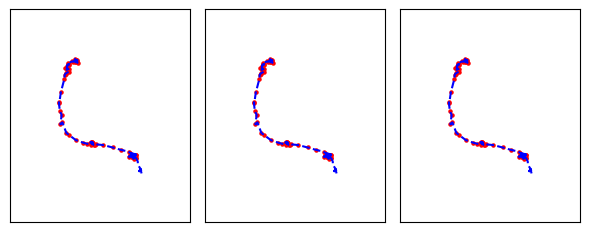

In [82]:
from skimage.segmentation import find_boundaries

def plot_movement_arrow(self, cell_idx, step=16, ch='nuc', ax=None, frame_id = None):
    cell_df = self.df[self.df['cell_idx'] == cell_idx].sort_values('frame')
    x_pos, y_pos = cell_df['centroid-x_nuc'].values, cell_df['centroid-y_nuc'].values
    x_pos_int, y_pos_int = x_pos.astype(int), y_pos.astype(int)

    x_pos_int = np.array([348-20, 416+20])
    y_pos_int = np.array([324-20, 419+20])

    img = self.nuc_img if ch == 'nuc' else self.mem_img
    num_df_frames = len(cell_df)
    if frame_id is None:
        frame_id = num_df_frames // 2
    nuc_frame = self.nuc_img[int(cell_df['frame'].iloc[frame_id])]
    mem_frame = self.mem_img[int(cell_df['frame'].iloc[frame_id])]
    # ax.imshow(frame, cmap='gray', interpolation='none')

    mem_frame_show = mem_frame[y_pos_int.min()-20:y_pos_int.max()+20, x_pos_int.min()-20:x_pos_int.max()+20]
    nuc_frame_show = nuc_frame[y_pos_int.min()-20:y_pos_int.max()+20, x_pos_int.min()-20:x_pos_int.max()+20]
    #ax.imshow(mem_frame_show, cmap='gray', interpolation='none')
    #self._plot_additive_composite(mem_frame_show, nuc_frame_show, ax=ax)

    # Get rid of x y axis ticks and labels
    ax.set_xticks([])
    ax.set_yticks([])

    ## Uncomment below to show masks and boundaries
    # for label in [dc_mem_mask, dc_nuc_mask]:                          
    #      label_frame = label[int(cell_df['frame'].iloc[frame_id])]
    #      label_frame_show = label_frame[y_pos_int.min()-20:y_pos_int.max()+20, x_pos_int.min()-20:x_pos_int.max()+20]
    #      mask_borders = find_boundaries(label_frame_show, mode='thick', )
    #      masks = np.ma.masked_where(mask_borders == 0, mask_borders)
    #      ax.imshow(masks, alpha=1, cmap='prism')

    offset_x, offset_y = x_pos_int.min()-20, y_pos_int.min()-20
    x_pos_offset, y_pos_offset = x_pos - offset_x, y_pos - offset_y

    vx, vy = self._calculate_motion_vector(x_pos, y_pos, moving_window=step)
    ax.plot(x_pos_offset, y_pos_offset, color='blue', alpha=1, linestyle='--')
    for t in range(0, len(x_pos)-step//2, 1):
        vec = [(vx[t]), (vy[t])]
        #ax.arrow(x_pos_offset[t], y_pos_offset[t], vec[0]/5, vec[1]/5, head_width=5, head_length=5, color='red', alpha=0.6)
        ax.scatter(x_pos_offset[t], y_pos_offset[t], color='r', s=5, alpha=1)

    # Make x y axis limits to be the same as the image
    ax.set_xlim(0, mem_frame_show.shape[1])
    ax.set_ylim(mem_frame_show.shape[0], 0)
    # Make aspect ratio equal
    ax.set_aspect('equal')

fig, axes = plt.subplots(1,3, figsize=(6,6))
plot_movement_arrow(cp, cell_idx=1, step=16, ch='nuc', ax=axes[0], frame_id = 32)
plot_movement_arrow(cp, cell_idx=1, step=16, ch='nuc', ax=axes[1], frame_id = 39)
plot_movement_arrow(cp, cell_idx=1, step=16, ch='nuc', ax=axes[2], frame_id = 46)
# Save figure
plt.tight_layout()
plt.savefig("cell_track.png", dpi=700)

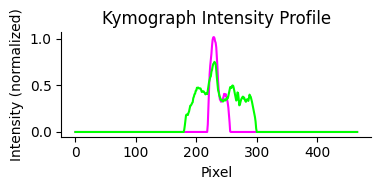

In [105]:
plt.figure(figsize=(4,2))
plt.plot(kymo_data[1]['nuc'][:,39]/300, color='magenta')
plt.plot(kymo_data[1]['mem'][:,39]/500, color='lime')
plt.xlabel("Pixel")
plt.ylabel("Intensity (normalized)")
plt.title("Kymograph Intensity Profile")
sns.despine()
# Save as svg
plt.tight_layout()
plt.savefig("kymo_intensity_profile.svg", dpi=700)

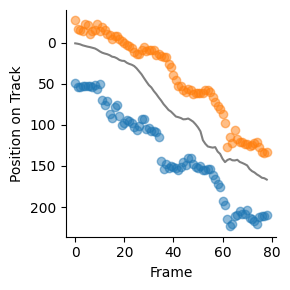

In [113]:
fig, ax = plt.subplots(figsize=(3,3))   
cp.plot_cell_props(cell_idx=1, prop='pos_on_track', ax=ax, color = 'k', alpha=0.5)
cp.plot_cell_props_scatter(cell_idx=1, prop='mem_front', ax=ax, marker='o', alpha=0.5)
cp.plot_cell_props_scatter(cell_idx=1, prop='mem_back', ax=ax, marker='o', alpha=0.5)
# Flip y axis so that it matches the image coordinates
ax.invert_yaxis()
ax.set_ylabel("Position on Track")
ax.set_xlabel("Frame")
sns.despine()
plt.tight_layout()
plt.savefig("position_on_track.svg", dpi=700)